 
# Architecture & Rationale: Localizing Vision-Language Models for Indian E-Commerce

Before diving into the pipeline, it is critical to understand *why* this specific architecture was chosen and *why* pre-trained foundational models fail at this specific task.

### 1. The Problem: The Western Bias of Base Models
Foundational Vision-Language Models (VLMs) like CLIP are trained on massive, internet-scale datasets (like LAION or WebImageText). These datasets are overwhelmingly Western-centric. While a base VLM can easily identify a "T-shirt" or "Jeans", it fundamentally lacks the localized semantic vocabulary to distinguish between a "Kurta", a "Sherwani", a "Lehenga", or a "Saree". 
* **The Goal:** By fine-tuning the model specifically on the Myntra dataset, we are forcing the model's text-encoder to learn Indian fashion terminology, bridging the cultural-semantic gap so that users can actually search for these items using natural, local language.

### 2. The Solution: Why SigLIP over CLIP?
Standard CLIP uses a **Softmax contrastive loss**. Softmax requires the model to calculate the similarities of all image-text pairs across an entire batch globally. To get good performance, CLIP requires massive batch sizes (e.g., 32,000+), which is mathematically impossible to fit into a Kaggle Tesla T4 GPU (16GB VRAM).
* **The SigLIP Advantage:** SigLIP replaces Softmax with a **Sigmoid loss**. It treats every single image-text pair as an independent binary classification problem. This completely removes the dependency on massive batch sizes. We can achieve state-of-the-art zero-shot and retrieval performance using small batch sizes (like 32 or 64) perfectly suited for our 16GB Kaggle environment.

> **Foundational Research:** > * [Sigmoid Loss for Language Image Pre-Training (Zhai et al., Google Research, 2023)](https://arxiv.org/abs/2303.15343)
> * [Learning Transferable Visual Models From Natural Language Supervision (Radford et al., OpenAI, 2021)](https://arxiv.org/abs/2103.00020)

In [1]:
# Install/upgrade required packages (safe to re-run)
!pip -q install -U transformers accelerate scikit-learn tqdm "pillow<11.0.0"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 83.5 MB/s eta 0:00:00:00:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 383.7/383.7 kB 25.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 88.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 93.0 MB/s eta 0:00:00:00:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dopamine-rl 4.1.2 requires gym<=0.25.2, but you have gym 0.26.2 which is incompatible.


## 1) Imports and Run Configuration

This cell initializes dependencies and reproducibility settings.

- Sets deterministic seeds for `random`, `numpy`, and `torch`.
- Defines the `Config` dataclass used across the notebook.
- Detects runtime device and persists `run_config.json` for traceability.

In [ ]:
import os
import gc
import json
import time
import random
from pathlib import Path
from dataclasses import dataclass, asdict

import numpy as np
import pandas as pd
from PIL import Image, UnidentifiedImageError
from tqdm.auto import tqdm
from sklearn.model_selection import train_test_split

import torch
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from transformers import AutoProcessor, SiglipModel, get_cosine_schedule_with_warmup

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

@dataclass
class Config:
    run_name: str = "run_005_conservative_retrieval_selected"
    model_name: str = "google/siglip-base-patch16-224"
    images_dir: str = "/kaggle/input/datasets/paramaggarwal/fashion-product-images-small/images"
    csv_dir: str = "/kaggle/input/datasets/paramaggarwal/fashion-product-images-small"
    output_root: str = "/kaggle/working/outputs"

    image_size: int = 224
    train_batch_size: int = 32
    eval_batch_size: int = 64
    grad_accum_steps: int = 2
    num_workers: int = 4

    # Conservative tuning settings
    epochs: int = 3
    lr: float = 5e-6
    weight_decay: float = 0.01
    warmup_ratio: float = 0.03
    max_grad_norm: float = 1.0
    fp16: bool = True

    min_samples_per_class: int = 5
    max_train_samples: int = 0
    max_val_samples: int = 0
    max_test_samples: int = 0

    # Prompt handling
    use_prompt_ensemble_train: bool = False

    # Retrieval evaluation
    k_values: tuple = (1, 5, 10, 20)
    retrieval_query_batch: int = 512

CFG = Config()
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
OUT_DIR = Path(CFG.output_root) / CFG.run_name
OUT_DIR.mkdir(parents=True, exist_ok=True)

print("Device:", DEVICE)
if DEVICE == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))
    print("VRAM(GB):", round(torch.cuda.get_device_properties(0).total_memory / 1e9, 2))

with open(OUT_DIR / "run_config.json", "w", encoding="utf-8") as f:
    json.dump(asdict(CFG), f, indent=2)

print("Output dir:", OUT_DIR)

Device: cuda
GPU: Tesla T4
VRAM(GB): 15.64
Output dir: /kaggle/working/outputs/run_005_conservative_retrieval_selected


## 2) Data Ingestion, Cleaning, and Prompt Engineering

This cell builds a reliable training table from raw metadata.

- Loads CSV metadata and validates required schema.
- Filters missing labels, missing files, duplicates, and unreadable images.
- Creates prompt candidates and a deterministic canonical prompt per sample.
- Preserves Indian fashion lexical cues for localization.

In [3]:
# -------- Data Load + Clean + Advanced Prompt Engineering --------
images_dir = Path(CFG.images_dir)
csv_dir = Path(CFG.csv_dir)

assert images_dir.exists(), f"Images dir not found: {images_dir}"

# Support both direct csv dir and parent dir layouts
if not csv_dir.exists():
    raise FileNotFoundError(f"CSV dir not found: {csv_dir}")

csv_candidates = sorted(csv_dir.rglob("*.csv"))
assert len(csv_candidates) > 0, f"No CSV found under {csv_dir}"

styles_csv = None
for c in csv_candidates:
    if c.name.lower() == "styles.csv" or "style" in c.name.lower():
        styles_csv = c
        break
if styles_csv is None:
    styles_csv = csv_candidates[0]

print("Using CSV:", styles_csv)
df = pd.read_csv(styles_csv, on_bad_lines="skip")
print("Raw rows:", len(df))

required_cols = ["id", "articleType"]
for c in required_cols:
    assert c in df.columns, f"Missing required column: {c}"

for optional_col in ["gender", "baseColour", "usage", "productDisplayName", "masterCategory", "subCategory", "season"]:
    if optional_col not in df.columns:
        df[optional_col] = "unknown"

df["id"] = df["id"].astype(str)
df["image_path"] = df["id"].apply(lambda x: str(images_dir / f"{x}.jpg"))

df = df[df["articleType"].notna()].copy()
df["articleType"] = df["articleType"].astype(str).str.strip()
df = df[df["articleType"] != ""].copy()

df = df[df["image_path"].apply(lambda p: Path(p).exists())].copy()
df = df.drop_duplicates(subset=["id"]).copy()

class_counts = df["articleType"].value_counts()
keep_classes = class_counts[class_counts >= CFG.min_samples_per_class].index
df = df[df["articleType"].isin(keep_classes)].copy()

def is_readable_image(path):
    try:
        with Image.open(path) as img:
            img.verify()
        return True
    except (UnidentifiedImageError, OSError, ValueError):
        return False

readable_mask = []
for p in tqdm(df["image_path"].tolist(), desc="Checking image readability"):
    readable_mask.append(is_readable_image(p))
df = df[np.array(readable_mask)].copy()

def _clean_token(v, default="unknown"):
    s = str(v).strip().lower()
    if s in {"", "nan", "none", "null", "na", "n/a", "unknown"}:
        return default
    return " ".join(s.split())

# Optional Indian style lexical enrichment
INDIAN_STYLE_HINTS = {
    "kurta": ["ethnicwear", "traditional indian"],
    "kurti": ["ethnicwear", "indian dailywear"],
    "saree": ["draped indian attire", "festive"],
    "lehenga": ["weddingwear", "festive"],
    "sherwani": ["groomwear", "ceremonial"],
    "dupatta": ["ethnic layer", "traditional accessory"],
    "salwar": ["ethnicwear", "comfort fit"],
    "churidar": ["ethnicwear", "traditional silhouette"],
    "anarkali": ["ethnic gown", "festive"],
}

def build_prompt_candidates(row):
    color = _clean_token(row.get("baseColour", "unknown"), default="")
    article = _clean_token(row.get("articleType", "fashion item"), default="fashion item")
    gender = _clean_token(row.get("gender", "unisex"), default="unisex")
    usage = _clean_token(row.get("usage", "casual"), default="casual")
    subcat = _clean_token(row.get("subCategory", ""), default="")
    master = _clean_token(row.get("masterCategory", "fashion"), default="fashion")
    season = _clean_token(row.get("season", ""), default="")
    display = _clean_token(row.get("productDisplayName", ""), default="")

    # Compact phrase blocks
    core = f"{color} {article}".strip() if color else article
    audience = "for men" if gender == "men" else ("for women" if gender == "women" else "for unisex wear")
    context = f"{usage} wear" if usage else "everyday wear"
    taxonomy = ", ".join([x for x in [subcat, master] if x])

    # Add style hints for Indian categories when available
    style_hints = []
    for k, hints in INDIAN_STYLE_HINTS.items():
        if k in article:
            style_hints.extend(hints)
    style_text = ", ".join(style_hints)

    templates = [
        f"a product photo of {core}, {audience}, {context}",
        f"fashion catalog image: {core}; category {taxonomy if taxonomy else master}; {audience}",
        f"indian fashion item: {display if display else core}; {context}; style {style_text if style_text else 'everyday style'}",
    ]

    # Lightweight prompt bagging cleanup
    cleaned = []
    for t in templates:
        t = " ".join(t.replace(";", ",").replace("  ", " ").split())
        if t not in cleaned:
            cleaned.append(t)
    return cleaned

df["prompt_candidates"] = df.apply(build_prompt_candidates, axis=1)
# Canonical evaluation prompt (deterministic)
df["text_prompt"] = df["prompt_candidates"].apply(lambda x: x[0] if isinstance(x, list) and len(x) else "a product photo of a fashion item")

df = df.reset_index(drop=True)

print("Clean rows:", len(df))
print("Unique classes:", df["articleType"].nunique())
print("Prompt candidates per sample (example):", len(df.loc[0, "prompt_candidates"]))
display(df[["id", "articleType", "text_prompt", "prompt_candidates"]].head(3))

Using CSV: /kaggle/input/datasets/paramaggarwal/fashion-product-images-small/myntradataset/styles.csv
Raw rows: 44424


Checking image readability:   0%|          | 0/44373 [00:00<?, ?it/s]

Clean rows: 44373
Unique classes: 123
Prompt candidates per sample (example): 3


,id,articleType,text_prompt,prompt_candidates
0,15970,Shirts,"a product photo of navy blue shirts, for men, ...","[a product photo of navy blue shirts, for men,..."
1,39386,Jeans,"a product photo of blue jeans, for men, casual...","[a product photo of blue jeans, for men, casua..."
2,59263,Watches,"a product photo of silver watches, for women, ...","[a product photo of silver watches, for women,..."


## 3) Train/Validation/Test Split

This cell creates robust evaluation splits.

- Performs stratified splitting with safe fallback when class support is low.
- Applies optional sample caps for quick experiments.
- Enforces strict no-overlap checks to prevent leakage.
- Exports split CSV files for reproducibility.

In [6]:
# -------- Split (robust stratification) --------
def safe_stratified_split(df_in, test_size, seed, label_col="articleType", stage_name="split"):
    """Try stratified split; fallback to random split if any class has <2 samples."""
    label_counts = df_in[label_col].value_counts()
    too_small = label_counts[label_counts < 2]

    if len(too_small) > 0:
        print(f"[WARN] {stage_name}: {len(too_small)} class(es) have <2 samples in this subset.")
        print("[WARN] Falling back to random split (non-stratified) for this stage.")
        return train_test_split(df_in, test_size=test_size, random_state=seed, shuffle=True)

    try:
        return train_test_split(
            df_in,
            test_size=test_size,
            stratify=df_in[label_col],
            random_state=seed
        )
    except ValueError as e:
        print(f"[WARN] {stage_name}: stratified split failed -> {e}")
        print("[WARN] Falling back to random split (non-stratified).")
        return train_test_split(df_in, test_size=test_size, random_state=seed, shuffle=True)

# 1) Main split: train (80) / temp (20)
train_df, temp_df = safe_stratified_split(
    df,
    test_size=0.2,
    seed=SEED,
    label_col="articleType",
    stage_name="train_vs_temp"
 )

# 2) Secondary split: val (10) / test (10) from temp
val_df, test_df = safe_stratified_split(
    temp_df,
    test_size=0.5,
    seed=SEED,
    label_col="articleType",
    stage_name="val_vs_test"
 )

if CFG.max_train_samples > 0:
    train_df = train_df.sample(min(CFG.max_train_samples, len(train_df)), random_state=SEED)
if CFG.max_val_samples > 0:
    val_df = val_df.sample(min(CFG.max_val_samples, len(val_df)), random_state=SEED)
if CFG.max_test_samples > 0:
    test_df = test_df.sample(min(CFG.max_test_samples, len(test_df)), random_state=SEED)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

train_ids = set(train_df["id"].tolist())
val_ids = set(val_df["id"].tolist())
test_ids = set(test_df["id"].tolist())

assert len(train_ids & val_ids) == 0, "Leakage: train-val overlap"
assert len(train_ids & test_ids) == 0, "Leakage: train-test overlap"
assert len(val_ids & test_ids) == 0, "Leakage: val-test overlap"

splits_dir = OUT_DIR / "splits"
splits_dir.mkdir(parents=True, exist_ok=True)
train_df.to_csv(splits_dir / "train.csv", index=False)
val_df.to_csv(splits_dir / "val.csv", index=False)
test_df.to_csv(splits_dir / "test.csv", index=False)

print(f"Train: {len(train_df)}, Val: {len(val_df)}, Test: {len(test_df)}")
print("Class counts (min):", {
    "train_min": int(train_df["articleType"].value_counts().min()),
    "val_min": int(val_df["articleType"].value_counts().min()),
    "test_min": int(test_df["articleType"].value_counts().min())
})

[WARN] val_vs_test: 11 class(es) have <2 samples in this subset.
[WARN] Falling back to random split (non-stratified) for this stage.
Train: 35498, Val: 4437, Test: 4438
Class counts (min): {'train_min': 4, 'val_min': 1, 'test_min': 1}


## 4) Dataset and DataLoader Pipeline

This cell prepares batches for model training and evaluation.

- Defines `FashionDataset` for image/text pairing.
- Uses resilient prompt selection for both list and string prompt formats.
- Configures DataLoaders with safe worker settings (`persistent_workers` only when valid).
- Reuses shared loader kwargs to reduce redundancy.

In [ ]:
# -------- Dataset / DataLoader --------
import ast
import re

processor = AutoProcessor.from_pretrained(CFG.model_name)

INDIAN_KEYWORDS = [
    "kurta", "kurti", "saree", "dupatta", "salwar", "churidar",
    "lehenga", "sherwani", "nehru jacket", "blouse", "ethnic dress",
    "tunic", "patiala", "dhoti", "anarkali"
 ]
INDIAN_PATTERN = re.compile(
    r"|".join([rf"\\b{re.escape(k)}s?\\b" for k in INDIAN_KEYWORDS]),
    flags=re.IGNORECASE
)

def dataloader_kwargs(num_workers):
    return {
        "num_workers": num_workers,
        "pin_memory": True,
        "persistent_workers": num_workers > 0
    }

def parse_prompt_candidates(value):
    if isinstance(value, list):
        return value
    if isinstance(value, str):
        try:
            parsed = ast.literal_eval(value)
            return parsed if isinstance(parsed, list) else [value]
        except (SyntaxError, ValueError):
            return [value]
    return []

def select_text_prompt(row, is_train=False, use_prompt_ensemble=False):
    cands = parse_prompt_candidates(row.get("prompt_candidates", []))
    if is_train and use_prompt_ensemble and len(cands) > 0:
        return random.choice(cands)
    if isinstance(row.get("text_prompt", None), str) and row["text_prompt"].strip():
        return row["text_prompt"]
    return cands[0] if len(cands) > 0 else "a product photo of a fashion item"

class FashionDataset(Dataset):
    def __init__(self, df, is_train=False, use_prompt_ensemble=True):
        self.df = df.reset_index(drop=True)
        self.is_train = is_train
        self.use_prompt_ensemble = use_prompt_ensemble

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        with Image.open(row["image_path"]) as im:
            image = im.convert("RGB")

        text = select_text_prompt(
            row,
            is_train=self.is_train,
            use_prompt_ensemble=self.use_prompt_ensemble
        )

        return {
            "image": image,
            "text": text,
            "articleType": row["articleType"],
            "id": row["id"],
            "image_path": row["image_path"]
        }

def collate_fn(batch):
    images = [b["image"] for b in batch]
    texts = [b["text"] for b in batch]
    enc = processor(images=images, text=texts, padding=True, truncation=True, return_tensors="pt")
    enc["articleType"] = [b["articleType"] for b in batch]
    enc["id"] = [b["id"] for b in batch]
    enc["image_path"] = [b["image_path"] for b in batch]
    return enc

train_ds = FashionDataset(train_df, is_train=True, use_prompt_ensemble=CFG.use_prompt_ensemble_train)
val_ds = FashionDataset(val_df, is_train=False)
test_ds = FashionDataset(test_df, is_train=False)

dlk = dataloader_kwargs(CFG.num_workers)

# Training loader
train_loader = DataLoader(
    train_ds, batch_size=CFG.train_batch_size, shuffle=True,
    collate_fn=collate_fn, **dlk
)

# Evaluation loaders
val_loader = DataLoader(
    val_ds, batch_size=CFG.eval_batch_size, shuffle=False,
    collate_fn=collate_fn, **dlk
)

train_eval_loader = DataLoader(
    FashionDataset(train_df, is_train=False),
    batch_size=CFG.eval_batch_size, shuffle=False,
    collate_fn=collate_fn, **dlk
)

test_loader = DataLoader(
    test_ds, batch_size=CFG.eval_batch_size, shuffle=False,
    collate_fn=collate_fn, **dlk
)

print("DataLoaders ready. Prompt ensemble in training:", CFG.use_prompt_ensemble_train)

DataLoaders ready. Prompt ensemble in training: False


## 5) Core Model and Retrieval Utilities

This cell defines reusable training and evaluation primitives.

- Loads SigLIP model.
- Implements contrastive loss and embedding extraction.
- Implements GPU-native `Recall@K`.
- Adds shared evaluation helpers to avoid duplicated baseline/finetuned logic.

In [ ]:
# -------- Model / Loss / Retrieval Helpers --------
# This cell defines all core reusable utilities for training and evaluation.
model = SiglipModel.from_pretrained(CFG.model_name).to(DEVICE)

def batch_to_device(batch, device):
    out = {}
    for k, v in batch.items():
        if isinstance(v, torch.Tensor):
            out[k] = v.to(device, non_blocking=True)
        else:
            out[k] = v
    return out

def clip_style_contrastive_loss(image_embeds, text_embeds, model_obj):
    image_embeds = F.normalize(image_embeds, dim=-1)
    text_embeds = F.normalize(text_embeds, dim=-1)

    if hasattr(model_obj, "logit_scale"):
        logit_scale = model_obj.logit_scale.exp()
    else:
        logit_scale = torch.tensor(1.0 / 0.07, device=image_embeds.device)

    logits_per_image = logit_scale * image_embeds @ text_embeds.T
    logits_per_text = logits_per_image.T
    labels = torch.arange(image_embeds.size(0), device=image_embeds.device)

    loss_i = F.cross_entropy(logits_per_image, labels)
    loss_t = F.cross_entropy(logits_per_text, labels)
    return 0.5 * (loss_i + loss_t)

def _unwrap_image_features(feats):
    if isinstance(feats, torch.Tensor):
        return feats
    if hasattr(feats, "image_embeds") and feats.image_embeds is not None:
        return feats.image_embeds
    if hasattr(feats, "pooler_output") and feats.pooler_output is not None:
        return feats.pooler_output
    if hasattr(feats, "last_hidden_state") and feats.last_hidden_state is not None:
        return feats.last_hidden_state.mean(dim=1)
    if isinstance(feats, (tuple, list)) and len(feats) > 0 and isinstance(feats[0], torch.Tensor):
        return feats[0]
    raise TypeError(f"Unsupported feature output type: {type(feats)}")

def extract_embeddings(model_obj, dataloader):
    """Extract normalized image embeddings from a dataloader."""
    model_obj.eval()
    img_embs = []
    labels = []
    ids = []

    with torch.inference_mode():
        for batch in tqdm(dataloader, desc="Embedding"):
            batch = batch_to_device(batch, DEVICE)

            with torch.amp.autocast(device_type="cuda", enabled=(CFG.fp16 and DEVICE == "cuda")):
                feats = model_obj.get_image_features(pixel_values=batch["pixel_values"])
                feats = _unwrap_image_features(feats)
                feats = F.normalize(feats, dim=-1)

            img_embs.append(feats)
            labels.extend(batch["articleType"])
            ids.extend(batch["id"])

    embs = torch.cat(img_embs, dim=0)
    return embs, np.array(labels), np.array(ids)

def recall_at_k(train_emb, train_labels, query_emb, query_labels, k_values=(1, 5, 10, 20), q_batch=512, show_progress=True):
    """Compute image-to-image retrieval Recall@K on GPU."""
    recalls = {int(k): 0 for k in k_values}
    max_k = int(max(k_values))
    n = len(query_labels)

    for s in tqdm(range(0, n, q_batch), desc="GPU Retrieval", disable=(not show_progress)):
        qe = query_emb[s:s + q_batch]
        ql = query_labels[s:s + q_batch]

        sims = qe @ train_emb.T
        _, topk_idx = torch.topk(sims, max_k, dim=1)
        topk_idx = topk_idx.cpu().numpy()
        retrieved_labels = train_labels[topk_idx]

        for i in range(len(ql)):
            for k in k_values:
                if ql[i] in retrieved_labels[i, :k]:
                    recalls[int(k)] += 1

    return {k: v / n for k, v in recalls.items()}

def per_class_recall_at_k(train_emb, train_labels, query_emb, query_labels, k_values=(1, 5, 10, 20), q_batch=512):
    rows = []
    q_labels = np.array(query_labels)
    unique_classes = sorted(pd.Series(q_labels).astype(str).unique())

    for cls in unique_classes:
        idx = np.where(q_labels.astype(str) == cls)[0]
        if len(idx) == 0:
            continue

        rec = recall_at_k(
            train_emb=train_emb,
            train_labels=train_labels,
            query_emb=query_emb[idx],
            query_labels=q_labels[idx],
            k_values=k_values,
            q_batch=q_batch,
            show_progress=False
        )

        row = {"class": cls, "support": int(len(idx))}
        for k in k_values:
            row[f"R@{k}"] = float(rec[int(k)])
        rows.append(row)

    if len(rows) == 0:
        return pd.DataFrame(columns=["class", "support", *[f"R@{k}" for k in k_values]])
    return pd.DataFrame(rows).sort_values(["R@1", "support"], ascending=[True, False]).reset_index(drop=True)

def load_weights_if_any(model_obj, checkpoint_path=None):
    if checkpoint_path is None:
        return None
    ckpt = torch.load(checkpoint_path, map_location=DEVICE)
    model_obj.load_state_dict(ckpt["model_state_dict"])
    model_obj.eval()
    return ckpt

def run_image_to_image_eval(model_obj, train_loader_eval, test_loader_eval, stage_name, checkpoint_path=None):
    ckpt = load_weights_if_any(model_obj, checkpoint_path=checkpoint_path)
    start = time.time()

    train_emb, train_lbl, _ = extract_embeddings(model_obj, train_loader_eval)
    test_emb, test_lbl, _ = extract_embeddings(model_obj, test_loader_eval)

    recalls = recall_at_k(
        train_emb=train_emb,
        train_labels=train_lbl,
        query_emb=test_emb,
        query_labels=test_lbl,
        k_values=CFG.k_values,
        q_batch=CFG.retrieval_query_batch
    )

    result = {
        "run_name": CFG.run_name,
        "stage": stage_name,
        "model": CFG.model_name,
        "k_values": list(CFG.k_values),
        "recall": recalls,
        "elapsed_sec": round(time.time() - start, 2)
    }
    if ckpt is not None:
        result["best_val_loss"] = float(ckpt.get("val_loss", 0.0))
    return result

model.safetensors:   0%|          | 0.00/813M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/408 [00:00<?, ?it/s]

## 6) Baseline Evaluation

This cell measures retrieval before fine-tuning.

- Runs image-to-image retrieval using the pre-trained model.
- Saves standardized metrics to `baseline_results.json`.
- Establishes the control benchmark for later comparison.

In [ ]:
# -------- Baseline Evaluation (before fine-tuning) --------
print("Running baseline image-to-image evaluation...")

baseline_result = run_image_to_image_eval(
    model_obj=model,
    train_loader_eval=train_eval_loader,
    test_loader_eval=test_loader,
    stage_name="baseline",
    checkpoint_path=None
)
baseline_recalls = baseline_result["recall"]

with open(OUT_DIR / "baseline_results.json", "w", encoding="utf-8") as f:
    json.dump(baseline_result, f, indent=2)

print("Baseline recall:", baseline_recalls)

Extracting Baseline Embeddings...


Embedding:   0%|          | 0/555 [00:00<?, ?it/s]

Embedding:   0%|          | 0/70 [00:00<?, ?it/s]

GPU Retrieval:   0%|          | 0/9 [00:00<?, ?it/s]

Baseline recall: {1: 0.8986029743127535, 5: 0.975214060387562, 10: 0.9864803965750338, 20: 0.9918882379450202}


## 7) Fine-Tuning Loop

This cell performs model optimization.

- Uses `AdamW`, cosine schedule, mixed precision, and gradient accumulation.
- Tracks training and validation loss per epoch.
- Selects best checkpoint using `val_r1` (tie-breaker: lower `val_loss`).
- Writes epoch logs to `train_log.csv`.

In [10]:
# -------- Train (Fine-Tuning Stage) --------
print("Starting Training Loop...")
optimizer = torch.optim.AdamW(model.parameters(), lr=CFG.lr, weight_decay=CFG.weight_decay)
total_steps = (len(train_loader) * CFG.epochs) // CFG.grad_accum_steps
warmup_steps = int(total_steps * CFG.warmup_ratio)
scheduler = get_cosine_schedule_with_warmup(optimizer, num_warmup_steps=warmup_steps, num_training_steps=max(total_steps, 1))
scaler = torch.amp.GradScaler("cuda", enabled=(CFG.fp16 and DEVICE == "cuda"))

best_val_loss = float("inf")
best_val_r1 = -1.0
train_logs = []
best_ckpt_path = OUT_DIR / "best_model.pt"

for epoch in range(1, CFG.epochs + 1):
    model.train()
    epoch_train_loss = 0.0
    optimizer.zero_grad(set_to_none=True)

    pbar = tqdm(train_loader, desc=f"Train Epoch {epoch}/{CFG.epochs}")
    for step, batch in enumerate(pbar, start=1):
        batch = batch_to_device(batch, DEVICE)
        input_keys = {k: v for k, v in batch.items() if isinstance(v, torch.Tensor)}

        with torch.amp.autocast(device_type="cuda", enabled=(CFG.fp16 and DEVICE == "cuda")):
            outputs = model(**input_keys)
            image_embeds = outputs.image_embeds
            text_embeds = outputs.text_embeds
            loss = clip_style_contrastive_loss(image_embeds, text_embeds, model)
            loss = loss / CFG.grad_accum_steps

        scaler.scale(loss).backward()
        epoch_train_loss += loss.item() * CFG.grad_accum_steps

        if step % CFG.grad_accum_steps == 0:
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), CFG.max_grad_norm)

            prev_scale = scaler.get_scale()
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad(set_to_none=True)

            if scaler.get_scale() >= prev_scale:
                scheduler.step()

        pbar.set_postfix(loss=float(loss.item() * CFG.grad_accum_steps))

    if len(train_loader) % CFG.grad_accum_steps != 0:
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), CFG.max_grad_norm)

        prev_scale = scaler.get_scale()
        scaler.step(optimizer)
        scaler.update()
        optimizer.zero_grad(set_to_none=True)
        if scaler.get_scale() >= prev_scale:
            scheduler.step()

    avg_train_loss = epoch_train_loss / max(len(train_loader), 1)

    # Validation loss
    model.eval()
    epoch_val_loss = 0.0
    with torch.no_grad():
        for batch in tqdm(val_loader, desc=f"Val Epoch {epoch}/{CFG.epochs}"):
            batch = batch_to_device(batch, DEVICE)
            input_keys = {k: v for k, v in batch.items() if isinstance(v, torch.Tensor)}
            with torch.amp.autocast(device_type="cuda", enabled=(CFG.fp16 and DEVICE == "cuda")):
                outputs = model(**input_keys)
                vloss = clip_style_contrastive_loss(outputs.image_embeds, outputs.text_embeds, model)
            epoch_val_loss += vloss.item()
    avg_val_loss = epoch_val_loss / max(len(val_loader), 1)

    # Validation retrieval R@1 (selection metric)
    train_emb_ep, train_lbl_ep, _ = extract_embeddings(model, train_eval_loader)
    val_emb_ep, val_lbl_ep, _ = extract_embeddings(model, val_loader)
    val_r1 = recall_at_k(
        train_emb=train_emb_ep,
        train_labels=train_lbl_ep,
        query_emb=val_emb_ep,
        query_labels=val_lbl_ep,
        k_values=(1,),
        q_batch=CFG.retrieval_query_batch
    )[1]

    log_row = {
        "epoch": epoch,
        "train_loss": float(avg_train_loss),
        "val_loss": float(avg_val_loss),
        "val_r1": float(val_r1),
        "lr": float(scheduler.get_last_lr()[0])
    }
    train_logs.append(log_row)
    print(log_row)

    # Select best checkpoint by retrieval quality first, tie-break with lower val loss
    is_better = (val_r1 > best_val_r1) or (val_r1 == best_val_r1 and avg_val_loss < best_val_loss)
    if is_better:
        best_val_r1 = float(val_r1)
        best_val_loss = float(avg_val_loss)
        print(f"New best checkpoint: val_r1={best_val_r1:.4f}, val_loss={best_val_loss:.4f}. Saving!")
        torch.save(
            {
                "epoch": epoch,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "scheduler_state_dict": scheduler.state_dict(),
                "val_loss": avg_val_loss,
                "val_r1": val_r1,
                "config": asdict(CFG)
            },
            best_ckpt_path
        )

pd.DataFrame(train_logs).to_csv(OUT_DIR / "train_log.csv", index=False)
print("Training log saved to:", OUT_DIR / "train_log.csv")
print("Best selection metric: val_r1 =", round(best_val_r1, 4), "| val_loss =", round(best_val_loss, 4))

Starting Training Loop...


Train Epoch 1/2:   0%|          | 0/1110 [00:00<?, ?it/s]

Val Epoch 1/2:   0%|          | 0/70 [00:00<?, ?it/s]

Embedding:   0%|          | 0/555 [00:00<?, ?it/s]

Embedding:   0%|          | 0/70 [00:00<?, ?it/s]

...

Val Epoch 2/2:   0%|          | 0/70 [00:00<?, ?it/s]

Embedding:   0%|          | 0/555 [00:00<?, ?it/s]

Embedding:   0%|          | 0/70 [00:00<?, ?it/s]

GPU Retrieval:   0%|          | 0/9 [00:00<?, ?it/s]

{'epoch': 2, 'train_loss': 0.220886261242983, 'val_loss': 0.4057090829525675, 'val_r1': 0.8961009691232815, 'lr': 1.701740784182393e-10}
New best checkpoint: val_r1=0.8961, val_loss=0.4057. Saving!
Training log saved to: /kaggle/working/outputs/run_005_conservative_retrieval_selected/train_log.csv
Best selection metric: val_r1 = 0.8961 | val_loss = 0.4057


## 8) Fine-Tuned Evaluation

This cell evaluates the best checkpoint and compares it against baseline.

- Loads `best_model.pt`.
- Reuses the same retrieval path as baseline for fair comparison.
- Saves `finetuned_results.json` and `comparison_summary.json`.

In [ ]:
# -------- Evaluate Fine-Tuned Model --------
print("Evaluating fine-tuned checkpoint...")

best_ckpt_path = OUT_DIR / "best_model.pt"
finetuned_result = run_image_to_image_eval(
    model_obj=model,
    train_loader_eval=train_eval_loader,
    test_loader_eval=test_loader,
    stage_name="finetuned",
    checkpoint_path=best_ckpt_path
)
finetuned_recalls = finetuned_result["recall"]

with open(OUT_DIR / "finetuned_results.json", "w", encoding="utf-8") as f:
    json.dump(finetuned_result, f, indent=2)

improvement = {
    f"R@{k}": round(finetuned_recalls[int(k)] - baseline_recalls[int(k)], 4)
    for k in CFG.k_values
}

summary = {
    "baseline": baseline_recalls,
    "finetuned": finetuned_recalls,
    "improvement": improvement
}

with open(OUT_DIR / "comparison_summary.json", "w", encoding="utf-8") as f:
    json.dump(summary, f, indent=2)

print("\n--- FINAL RESULTS ---")
print("Baseline:", baseline_recalls)
print("Fine-tuned:", finetuned_recalls)
print("Improvement:", improvement)

Evaluating Fine-Tuned Model...
Extracting Fine-Tuned Embeddings...


Embedding:   0%|          | 0/555 [00:00<?, ?it/s]

Embedding:   0%|          | 0/70 [00:00<?, ?it/s]

GPU Retrieval:   0%|          | 0/9 [00:00<?, ?it/s]


--- FINAL RESULTS ---
Baseline: {1: 0.8986029743127535, 5: 0.975214060387562, 10: 0.9864803965750338, 20: 0.9918882379450202}
Fine-tuned: {1: 0.8938711131140153, 5: 0.9720594862550699, 10: 0.9853537629562866, 20: 0.9896349707075259}
Improvement: {'R@1': -0.0047, 'R@5': -0.0032, 'R@10': -0.0011, 'R@20': -0.0023}


## 9) Artifact Export and Packaging

This cell exports deployment-ready artifacts.

- Saves full checkpoint and state dict.
- Exports Hugging Face model and processor assets.
- Persists run metadata and ONNX conversion notes.
- Creates a zip bundle for download and reuse.

In [12]:
# -------- Export Artifacts for Local Deployment (PT + HF + metadata only) --------
import pickle
import shutil
from pathlib import Path
import torch

EXPORT_DIR = OUT_DIR / "export"
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

# 1) Load best fine-tuned checkpoint
best_ckpt_path = OUT_DIR / "best_model.pt"
if not best_ckpt_path.exists():
    raise FileNotFoundError(f"Best checkpoint not found: {best_ckpt_path}")

ckpt = torch.load(best_ckpt_path, map_location=DEVICE)
model.load_state_dict(ckpt["model_state_dict"])
model.eval()

# 2) Save model in robust formats for local use
torch.save(ckpt, EXPORT_DIR / "best_model_full.pt")
torch.save(model.state_dict(), EXPORT_DIR / "best_model_state_dict.pt")

# 3) Save Hugging Face style files (recommended for later ONNX conversion)
model.save_pretrained(EXPORT_DIR / "hf_model")
processor.save_pretrained(EXPORT_DIR / "hf_processor")

# 4) Save lightweight run metadata
run_meta = {
    "run_name": CFG.run_name,
    "model_name": CFG.model_name,
    "best_val_loss": ckpt.get("val_loss", None),
    "best_val_r1": ckpt.get("val_r1", None),
    "k_values": list(CFG.k_values),
    "device_exported_from": DEVICE,
    "onnx_status": "not_exported_in_notebook"
}
with open(EXPORT_DIR / "run_metadata.pkl", "wb") as f:
    pickle.dump(run_meta, f)

# 5) Save ONNX conversion note for local post-download conversion
onnx_note = [
    "ONNX export intentionally skipped in this notebook runtime.",
    "Convert to ONNX after download in a clean local/Colab environment.",
    "Use hf_model/ and hf_processor/ as conversion source.",
    "Recommended: torch.onnx.export(..., dynamo=False) for compatibility."
]
with open(EXPORT_DIR / "ONNX_CONVERSION_NOTE.txt", "w", encoding="utf-8") as f:
    f.write("\n".join(onnx_note))

# 6) Zip all outputs for easy download
zip_path = Path("/kaggle/working/clipindia_export_bundle.zip")
if zip_path.exists():
    zip_path.unlink()
shutil.make_archive("/kaggle/working/clipindia_export_bundle", "zip", str(EXPORT_DIR))

print("Export completed (PT + HF only).")
print("Export dir:", EXPORT_DIR)
print("Bundle:", zip_path)
for p in sorted(EXPORT_DIR.glob("*")):
    print("-", p.name)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Export completed (PT + HF only).
Export dir: /kaggle/working/outputs/run_005_conservative_retrieval_selected/export
Bundle: /kaggle/working/clipindia_export_bundle.zip
- ONNX_CONVERSION_NOTE.txt
- best_model_full.pt
- best_model_state_dict.pt
- hf_model
- hf_processor
- run_metadata.pkl


## 10) Indian-Category Diagnostics

This section validates whether localization helped target categories.

- Filters classes using Indian fashion keywords.
- Compares per-class baseline vs fine-tuned retrieval.
- Exports category-level comparison table and visual diagnostics.

,class,support,R@1_baseline,R@5_baseline,R@10_baseline,R@20_baseline,R@1_finetuned,R@5_finetuned,R@10_finetuned,R@20_finetuned
0,Tunics,26,0.269231,0.576923,0.807692,0.923077,0.346154,0.653846,0.769231,0.884615
1,Churidar,3,0.333333,1.000000,1.000000,1.000000,0.666667,1.000000,1.000000,1.000000
2,Kurtis,19,0.473684,0.736842,0.842105,0.894737,0.315789,0.736842,0.789474,0.842105
3,Patiala,4,0.750000,1.000000,1.000000,1.000000,0.750000,1.000000,1.000000,1.000000
4,Kurta Sets,9,0.888889,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
5,Kurtas,181,0.906077,0.988950,0.988950,0.988950,0.922652,0.988950,0.988950,0.988950
6,Sarees,37,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
7,Dupatta,10,1.000000,1.000000,1.000000,1.000000,0.900000,1.000000,1.000000,1.000000
8,Salwar,3,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
9,Salwar and Dupatta,1,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


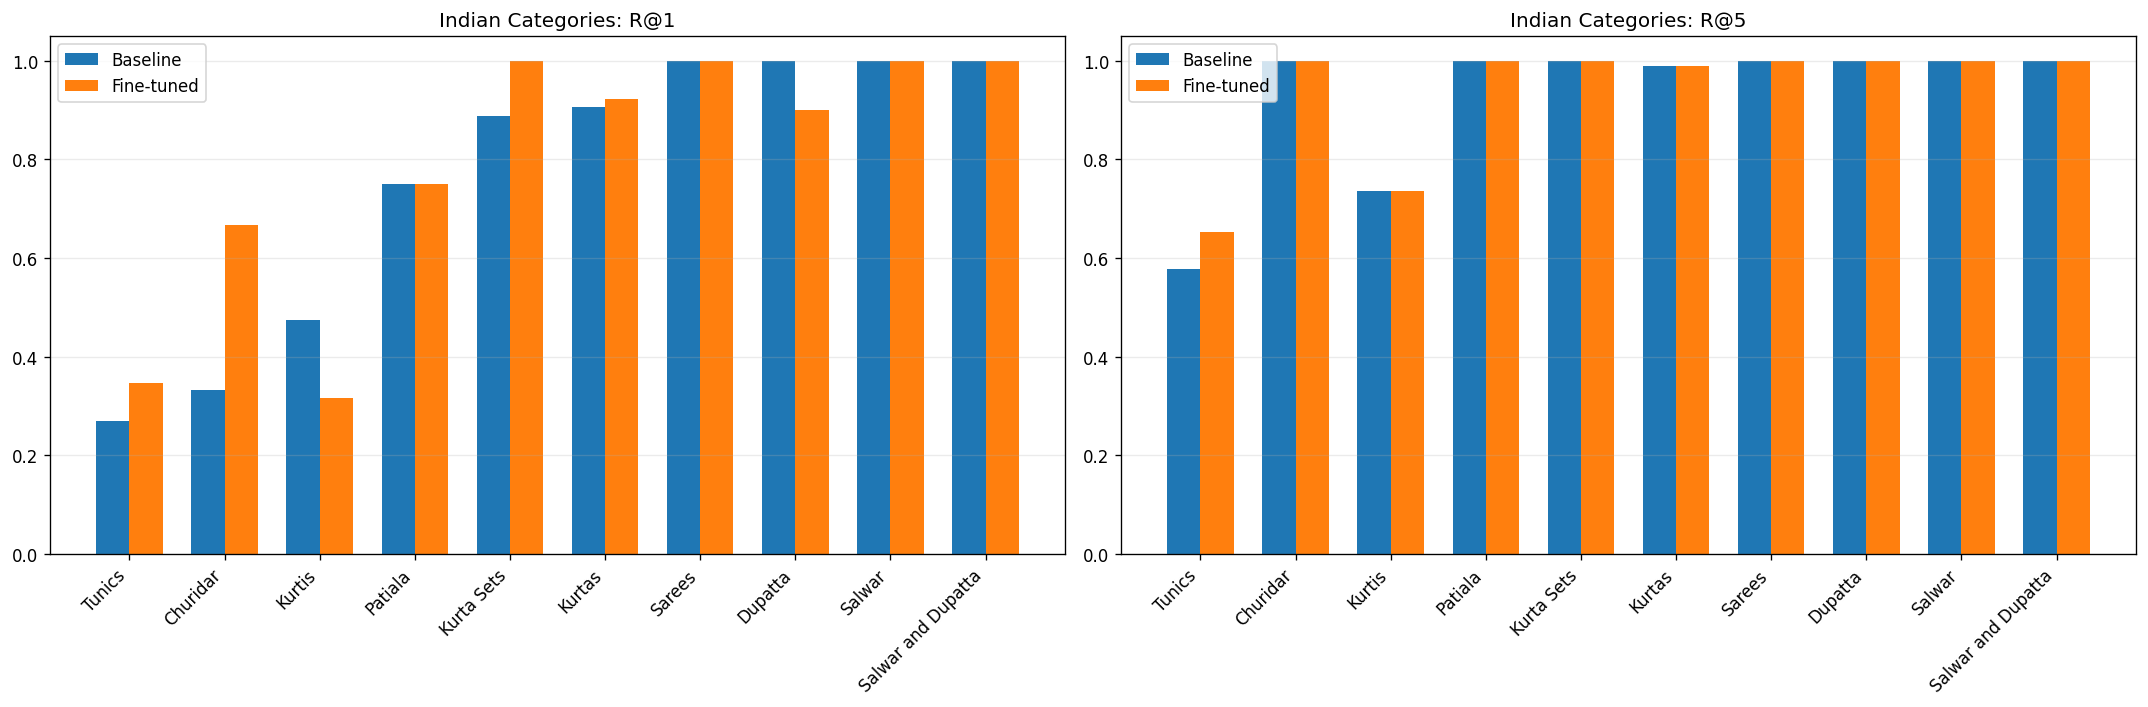

Saved: /kaggle/working/outputs/run_005_conservative_retrieval_selected/indian_category_baseline_vs_finetuned.csv


In [ ]:
# -------- Comparison Plot 1: Baseline vs Fine-Tuned on Indian Categories --------
import matplotlib.pyplot as plt

# Build per-class tables if not already present
if "per_class_base" not in globals():
    per_class_base = per_class_recall_at_k(
        train_emb=train_emb_b,
        train_labels=train_lbl_b,
        query_emb=test_emb_b,
        query_labels=test_lbl_b,
        k_values=CFG.k_values,
        q_batch=CFG.retrieval_query_batch
    )

if "per_class_ft" not in globals():
    per_class_ft = per_class_recall_at_k(
        train_emb=train_emb_f,
        train_labels=train_lbl_f,
        query_emb=test_emb_f,
        query_labels=test_lbl_f,
        k_values=CFG.k_values,
        q_batch=CFG.retrieval_query_batch
    )

base = per_class_base.copy()
ft = per_class_ft.copy()
base["class_norm"] = base["class"].astype(str).str.strip().str.lower()
ft["class_norm"] = ft["class"].astype(str).str.strip().str.lower()

base_i = base[base["class_norm"].str.contains(INDIAN_PATTERN, na=False)].copy()
ft_i = ft[ft["class_norm"].str.contains(INDIAN_PATTERN, na=False)].copy()

cmp_df = base_i[["class", "support", "R@1", "R@5", "R@10", "R@20"]].merge(
    ft_i[["class", "R@1", "R@5", "R@10", "R@20"]],
    on="class",
    suffixes=("_baseline", "_finetuned")
)

cmp_df = cmp_df.sort_values("R@1_baseline", ascending=True).reset_index(drop=True)
cmp_df.to_csv(OUT_DIR / "indian_category_baseline_vs_finetuned.csv", index=False)
display(cmp_df)

# Grouped bar charts for R@1 and R@5
x = np.arange(len(cmp_df))
w = 0.35

fig, axes = plt.subplots(1, 2, figsize=(18, 6), dpi=120)

axes[0].bar(x - w/2, cmp_df["R@1_baseline"], width=w, label="Baseline")
axes[0].bar(x + w/2, cmp_df["R@1_finetuned"], width=w, label="Fine-tuned")
axes[0].set_title("Indian Categories: R@1")
axes[0].set_xticks(x)
axes[0].set_xticklabels(cmp_df["class"], rotation=45, ha="right")
axes[0].set_ylim(0, 1.05)
axes[0].legend()
axes[0].grid(axis="y", alpha=0.25)

axes[1].bar(x - w/2, cmp_df["R@5_baseline"], width=w, label="Baseline")
axes[1].bar(x + w/2, cmp_df["R@5_finetuned"], width=w, label="Fine-tuned")
axes[1].set_title("Indian Categories: R@5")
axes[1].set_xticks(x)
axes[1].set_xticklabels(cmp_df["class"], rotation=45, ha="right")
axes[1].set_ylim(0, 1.05)
axes[1].legend()
axes[1].grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.show()

print("Saved:", OUT_DIR / "indian_category_baseline_vs_finetuned.csv")

## 11) Delta Analysis by Class

This section highlights where the model improved or regressed.

- Computes $\Delta$Recall = Fine-tuned $-$ Baseline.
- Renders heatmap across `R@1`, `R@5`, `R@10`, `R@20`.
- Renders class-wise $\Delta R@1$ bar chart.
- Saves delta table for error analysis and next-iteration planning.

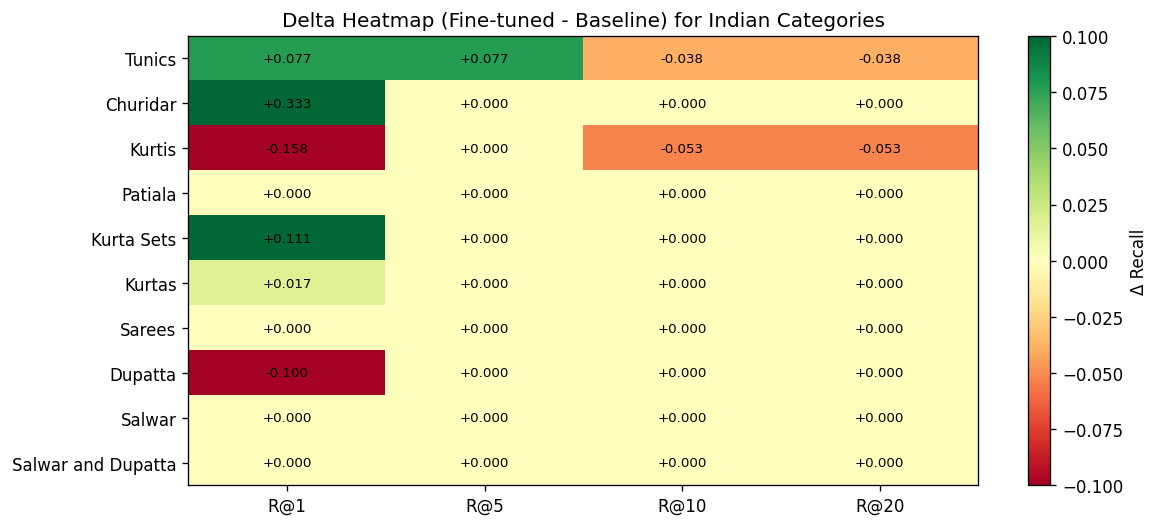

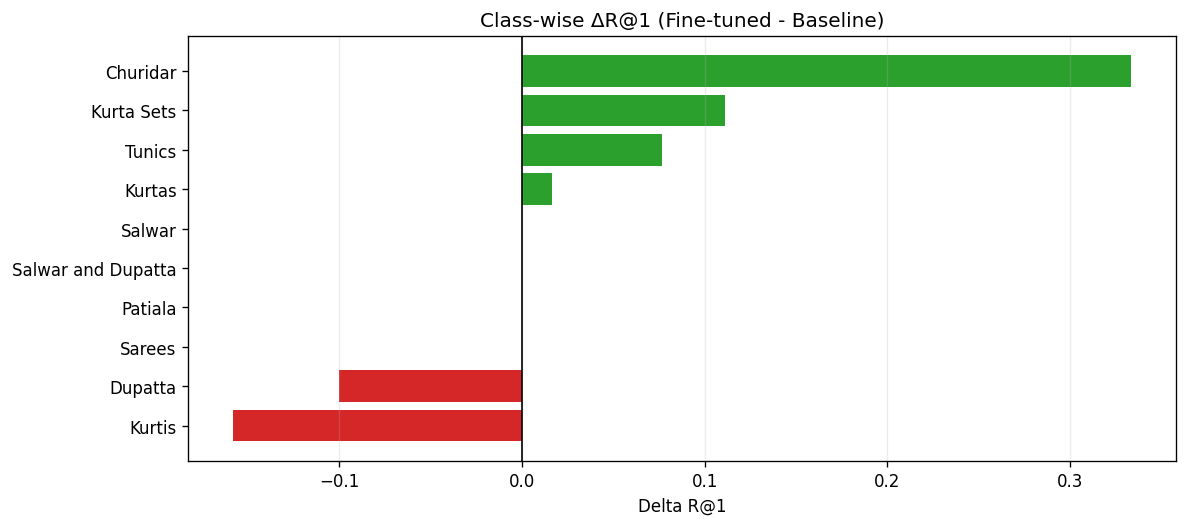

Saved: /kaggle/working/outputs/run_005_conservative_retrieval_selected/indian_category_deltas.csv


In [15]:
# -------- Comparison Plot 2: Delta Heatmap + Class-wise ΔR@1 --------
import numpy as np
import matplotlib.pyplot as plt

if "cmp_df" not in globals():
    raise RuntimeError("Run previous comparison cell first to create cmp_df")

delta_cols = ["R@1", "R@5", "R@10", "R@20"]
delta_mat = np.column_stack([
    cmp_df[f"{k}_finetuned"].values - cmp_df[f"{k}_baseline"].values
    for k in delta_cols
])

# Plot A: Heatmap of baseline->finetuned deltas
fig, ax = plt.subplots(figsize=(10, max(4, len(cmp_df) * 0.45)), dpi=120)
im = ax.imshow(delta_mat, cmap="RdYlGn", aspect="auto", vmin=-0.1, vmax=0.1)
ax.set_title("Delta Heatmap (Fine-tuned - Baseline) for Indian Categories")
ax.set_xticks(np.arange(len(delta_cols)))
ax.set_xticklabels(delta_cols)
ax.set_yticks(np.arange(len(cmp_df)))
ax.set_yticklabels(cmp_df["class"])

for i in range(delta_mat.shape[0]):
    for j in range(delta_mat.shape[1]):
        ax.text(j, i, f"{delta_mat[i, j]:+.3f}", ha="center", va="center", fontsize=8)

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Δ Recall")
plt.tight_layout()
plt.show()

# Plot B: Horizontal bar chart for ΔR@1
delta_r1 = cmp_df["R@1_finetuned"] - cmp_df["R@1_baseline"]
order = np.argsort(delta_r1.values)

fig, ax = plt.subplots(figsize=(10, max(4, len(cmp_df) * 0.45)), dpi=120)
colors = ["#d62728" if v < 0 else "#2ca02c" for v in delta_r1.values[order]]
ax.barh(cmp_df["class"].values[order], delta_r1.values[order], color=colors)
ax.axvline(0, color="black", linewidth=1)
ax.set_title("Class-wise ΔR@1 (Fine-tuned - Baseline)")
ax.set_xlabel("Delta R@1")
ax.grid(axis="x", alpha=0.25)
plt.tight_layout()
plt.show()

# Save deltas
for k in delta_cols:
    cmp_df[f"delta_{k}"] = cmp_df[f"{k}_finetuned"] - cmp_df[f"{k}_baseline"]
cmp_df.to_csv(OUT_DIR / "indian_category_deltas.csv", index=False)
print("Saved:", OUT_DIR / "indian_category_deltas.csv")

## 12) Text→Image Fairness Evaluation

This section checks cross-modal retrieval quality, not just image→image.

- Evaluates baseline and fine-tuned Text→Image Recall@K.
- Reports absolute delta across all `K` values.
- Validates semantic usefulness for real user search behavior.

In [16]:
# -------- Fair Evaluation Add-on: Text -> Image Recall@K (Baseline vs Fine-tuned) --------
import numpy as np
import torch
import torch.nn.functional as F
from tqdm.auto import tqdm

def extract_text_embeddings(model_obj, dataloader):
    """Extract text embeddings from loader batches; supports missing attention_mask."""
    model_obj.eval()
    txt_embs, labels = [], []

    with torch.inference_mode():
        for batch in tqdm(dataloader, desc="Text Embedding"):
            batch = batch_to_device(batch, DEVICE)

            text_kwargs = {"input_ids": batch["input_ids"]}
            if "attention_mask" in batch:
                text_kwargs["attention_mask"] = batch["attention_mask"]

            with torch.amp.autocast(device_type="cuda", enabled=(CFG.fp16 and DEVICE == "cuda")):
                feats = model_obj.get_text_features(**text_kwargs)
                if not isinstance(feats, torch.Tensor):
                    if hasattr(feats, "text_embeds") and feats.text_embeds is not None:
                        feats = feats.text_embeds
                    elif hasattr(feats, "pooler_output") and feats.pooler_output is not None:
                        feats = feats.pooler_output
                    elif isinstance(feats, (tuple, list)) and len(feats) > 0:
                        feats = feats[0]
                    else:
                        raise TypeError(f"Unsupported text output type: {type(feats)}")
                feats = F.normalize(feats, dim=-1)

            txt_embs.append(feats)
            labels.extend(batch["articleType"])

    txt_embs = torch.cat(txt_embs, dim=0)
    return txt_embs, np.array(labels)

def recall_text_to_image_at_k(train_img_emb, train_img_labels, query_txt_emb, query_txt_labels, k_values=(1,5,10,20), q_batch=512):
    recalls = {int(k): 0 for k in k_values}
    max_k = int(max(k_values))
    n = len(query_txt_labels)

    for s in tqdm(range(0, n, q_batch), desc="Text->Image Retrieval"):
        qe = query_txt_emb[s:s + q_batch]
        ql = query_txt_labels[s:s + q_batch]

        sims = qe @ train_img_emb.T
        _, topk_idx = torch.topk(sims, max_k, dim=1)
        topk_idx = topk_idx.cpu().numpy()
        retrieved_labels = train_img_labels[topk_idx]

        for i in range(len(ql)):
            for k in k_values:
                if ql[i] in retrieved_labels[i, :k]:
                    recalls[int(k)] += 1

    return {k: v / n for k, v in recalls.items()}

# --- Baseline checkpoint eval ---
baseline_model = SiglipModel.from_pretrained(CFG.model_name).to(DEVICE)
baseline_model.eval()
train_img_b, train_lbl_b2, _ = extract_embeddings(baseline_model, train_eval_loader)
test_txt_b, test_txt_lbl_b = extract_text_embeddings(baseline_model, test_loader)
t2i_base = recall_text_to_image_at_k(train_img_b, train_lbl_b2, test_txt_b, test_txt_lbl_b, CFG.k_values, CFG.retrieval_query_batch)
print("Baseline Text->Image Recall:", t2i_base)

# --- Fine-tuned checkpoint eval ---
finetuned_model = SiglipModel.from_pretrained(CFG.model_name).to(DEVICE)
best_ckpt_path = OUT_DIR / "best_model.pt"
finetuned_model.load_state_dict(torch.load(best_ckpt_path, map_location=DEVICE)["model_state_dict"])
finetuned_model.eval()
train_img_f, train_lbl_f2, _ = extract_embeddings(finetuned_model, train_eval_loader)
test_txt_f, test_txt_lbl_f = extract_text_embeddings(finetuned_model, test_loader)
t2i_ft = recall_text_to_image_at_k(train_img_f, train_lbl_f2, test_txt_f, test_txt_lbl_f, CFG.k_values, CFG.retrieval_query_batch)
print("Fine-tuned Text->Image Recall:", t2i_ft)

print("Delta:", {f"R@{k}": round(t2i_ft[k] - t2i_base[k], 4) for k in CFG.k_values})

Loading weights:   0%|          | 0/408 [00:00<?, ?it/s]

Embedding:   0%|          | 0/555 [00:00<?, ?it/s]

Text Embedding:   0%|          | 0/70 [00:00<?, ?it/s]

Text->Image Retrieval:   0%|          | 0/9 [00:00<?, ?it/s]

Baseline Text->Image Recall: {1: 0.07796304641730509, 5: 0.13181613339342046, 10: 0.20414601171698962, 20: 0.24290220820189273}


Loading weights:   0%|          | 0/408 [00:00<?, ?it/s]

Embedding:   0%|          | 0/555 [00:00<?, ?it/s]

Text Embedding:   0%|          | 0/70 [00:00<?, ?it/s]

Text->Image Retrieval:   0%|          | 0/9 [00:00<?, ?it/s]

Fine-tuned Text->Image Recall: {1: 0.9051374493014872, 5: 0.9788192879675529, 10: 0.9889589905362776, 20: 0.9936908517350158}
Delta: {'R@1': 0.8272, 'R@5': 0.847, 'R@10': 0.7848, 'R@20': 0.7508}


## 13) Indian-Only Text→Image Evaluation

This final section isolates Text→Image retrieval for Indian fashion classes.

- Filters test queries using the shared Indian-category matcher.
- Computes overall and per-class baseline vs fine-tuned Recall@K.
- Visualizes and exports localization impact for search-centric use cases.

Text->Image Retrieval:   0%|          | 0/1 [00:00<?, ?it/s]

Text->Image Retrieval:   0%|          | 0/1 [00:00<?, ?it/s]

Baseline Text->Image Recall (Indian categories): {1: 0.0, 5: 0.023890784982935155, 10: 0.20477815699658702, 20: 0.3003412969283277}
Fine-tuned Text->Image Recall (Indian categories): {1: 0.8361774744027304, 5: 0.9590443686006825, 10: 0.9726962457337884, 20: 0.9795221843003413}
Delta: {'R@1': 0.8362, 'R@5': 0.9352, 'R@10': 0.7679, 'R@20': 0.6792}


Text->Image Retrieval:   0%|          | 0/1 [00:00<?, ?it/s]

Text->Image Retrieval:   0%|          | 0/1 [00:00<?, ?it/s]

...

Text->Image Retrieval:   0%|          | 0/1 [00:00<?, ?it/s]

Text->Image Retrieval:   0%|          | 0/1 [00:00<?, ?it/s]

Text->Image Retrieval:   0%|          | 0/1 [00:00<?, ?it/s]

Text->Image Retrieval:   0%|          | 0/1 [00:00<?, ?it/s]

,class,support,R@1_baseline,R@5_baseline,R@10_baseline,R@20_baseline,R@1_finetuned,R@5_finetuned,R@10_finetuned,R@20_finetuned
0,Kurtas,181,0.0,0.022099,0.314917,0.386740,0.983425,1.000000,1.000000,1.000000
1,Sarees,37,0.0,0.081081,0.081081,0.378378,0.810811,1.000000,1.000000,1.000000
2,Tunics,26,0.0,0.000000,0.000000,0.153846,0.538462,1.000000,1.000000,1.000000
3,Kurtis,19,0.0,0.000000,0.000000,0.000000,0.473684,0.842105,0.842105,0.894737
4,Dupatta,10,0.0,0.000000,0.000000,0.000000,0.500000,1.000000,1.000000,1.000000
5,Kurta Sets,9,0.0,0.000000,0.000000,0.000000,0.555556,0.555556,0.555556,0.555556
6,Patiala,4,0.0,0.000000,0.000000,0.000000,0.750000,0.750000,1.000000,1.000000
7,Churidar,3,0.0,0.000000,0.000000,0.000000,0.000000,0.666667,0.666667,1.000000
8,Salwar,3,0.0,0.000000,0.000000,0.000000,0.333333,0.333333,1.000000,1.000000
9,Salwar and Dupatta,1,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000


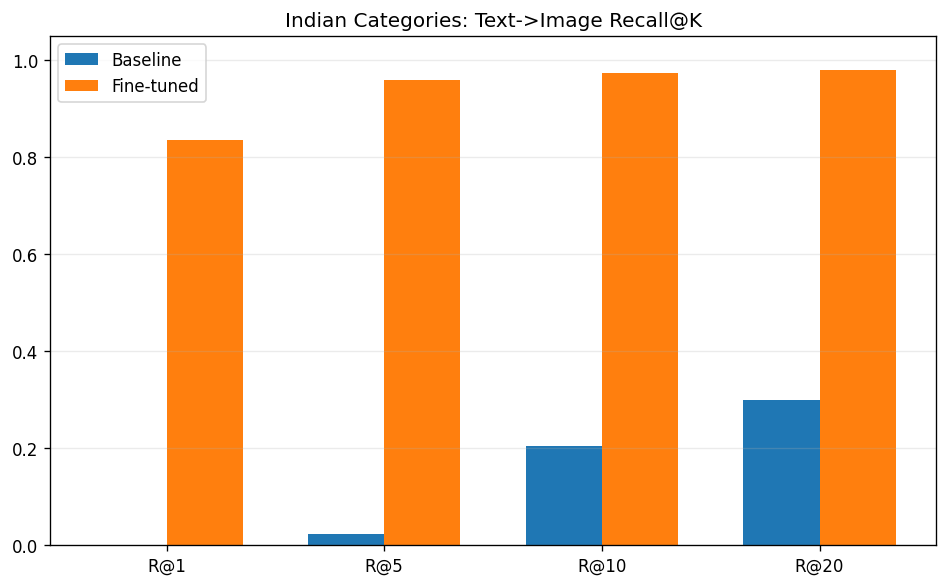

Saved: /kaggle/working/outputs/run_005_conservative_retrieval_selected/indian_text_to_image_per_class_baseline_vs_finetuned.csv


In [ ]:
# -------- Indian Categories Only: Text->Image Recall (Baseline vs Fine-tuned) --------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Requires previous cell outputs:
# train_img_b, train_lbl_b2, test_txt_b, test_txt_lbl_b, t2i_base
# train_img_f, train_lbl_f2, test_txt_f, test_txt_lbl_f, t2i_ft

if "test_txt_lbl_b" not in globals() or "test_txt_lbl_f" not in globals():
    raise RuntimeError("Run the previous Text->Image comparison cell first.")

def _indian_mask(labels):
    s = pd.Series(labels).astype(str).str.strip().str.lower()
    return s.str.contains(INDIAN_PATTERN, na=False).values

mask_b = _indian_mask(test_txt_lbl_b)
mask_f = _indian_mask(test_txt_lbl_f)

if mask_b.sum() == 0 or mask_f.sum() == 0:
    raise RuntimeError("No Indian-category text queries found in test split.")

# Overall Indian-only text->image recall
t2i_base_indian = recall_text_to_image_at_k(
    train_img_b, train_lbl_b2, test_txt_b[mask_b], np.array(test_txt_lbl_b)[mask_b], CFG.k_values, CFG.retrieval_query_batch
)
t2i_ft_indian = recall_text_to_image_at_k(
    train_img_f, train_lbl_f2, test_txt_f[mask_f], np.array(test_txt_lbl_f)[mask_f], CFG.k_values, CFG.retrieval_query_batch
)

print("Baseline Text->Image Recall (Indian categories):", t2i_base_indian)
print("Fine-tuned Text->Image Recall (Indian categories):", t2i_ft_indian)
print("Delta:", {f"R@{k}": round(t2i_ft_indian[k] - t2i_base_indian[k], 4) for k in CFG.k_values})

# Per-class Indian text->image recall
def per_class_t2i(train_img_emb, train_img_labels, query_txt_emb, query_txt_labels, k_values=(1,5,10,20), q_batch=512):
    rows = []
    labels = pd.Series(query_txt_labels).astype(str)
    for cls in sorted(labels.unique()):
        idx = np.where(labels.values == cls)[0]
        rec = recall_text_to_image_at_k(
            train_img_emb, train_img_labels, query_txt_emb[idx], labels.values[idx], k_values, q_batch
        )
        rows.append({"class": cls, "support": len(idx), **{f"R@{k}": rec[k] for k in k_values}})
    return pd.DataFrame(rows).sort_values(["R@1", "support"], ascending=[True, False]).reset_index(drop=True)

b_df = per_class_t2i(train_img_b, train_lbl_b2, test_txt_b[mask_b], np.array(test_txt_lbl_b)[mask_b], CFG.k_values, CFG.retrieval_query_batch)
f_df = per_class_t2i(train_img_f, train_lbl_f2, test_txt_f[mask_f], np.array(test_txt_lbl_f)[mask_f], CFG.k_values, CFG.retrieval_query_batch)

cmp_i = b_df[["class", "support", "R@1", "R@5", "R@10", "R@20"]].merge(
    f_df[["class", "R@1", "R@5", "R@10", "R@20"]], on="class", suffixes=("_baseline", "_finetuned")
)
display(cmp_i)

# Graph: Indian-only overall baseline vs fine-tuned
k_labels = [f"R@{k}" for k in CFG.k_values]
base_vals = [t2i_base_indian[k] for k in CFG.k_values]
ft_vals = [t2i_ft_indian[k] for k in CFG.k_values]
x = np.arange(len(k_labels))
w = 0.35

fig, ax = plt.subplots(figsize=(8, 5), dpi=120)
ax.bar(x - w/2, base_vals, width=w, label="Baseline")
ax.bar(x + w/2, ft_vals, width=w, label="Fine-tuned")
ax.set_xticks(x)
ax.set_xticklabels(k_labels)
ax.set_ylim(0, 1.05)
ax.set_title("Indian Categories: Text->Image Recall@K")
ax.grid(axis="y", alpha=0.25)
ax.legend()
plt.tight_layout()
plt.show()

cmp_i.to_csv(OUT_DIR / "indian_text_to_image_per_class_baseline_vs_finetuned.csv", index=False)
print("Saved:", OUT_DIR / "indian_text_to_image_per_class_baseline_vs_finetuned.csv")